<img src='../OUTILS/bandeau_MF.png' align='right' width='100%'/>

<div class="alert alert-info" role="alert">
<h3>Manipulation des données d'imagerie avec la librairie gdal </h3></div>

## <a id='TOC-TOP'></a>Contenus

Tout d'abord, il faut procéder à l'importation des librairies nécessaires à ce TP.

In [6]:
from satpy.scene import Scene
from satpy import find_files_and_readers
from datetime import datetime
import sys
from pyresample.geometry import AreaDefinition
import numpy as np
import os
from osgeo import gdal
from PIL import Image
import subprocess
from IPython.display import display,HTML
os.environ['PATH'] = f"/opt/conda/env_MF_teledetection/bin:{os.environ['PATH']}" 
os.environ['PATH'] = f"~/.conda/envs/env_MF_teledetection/bin:{os.environ['PATH']}"
os.environ['GDAL_DATA'] = '/opt/conda/env_MF_teledetection/share/gdal'
os.environ['PROJ_LIB'] = '/opt/conda/env_MF_teledetection/share/proj'

Ce TP utilise en grande partie les logiciels de la librairie **"gdal"** qui signifie : *geospatial data abstraction library*. Cette librairie est extrêmement utile pour manipuler les données issues des satellites météorologiques.

Pour ce TP nous allons utiliser des fichiers au format **TIF** issus de la production opérationnelle de Météo-France.  </br>
Ces fichiers TIF sont proposés selon la nomenclature suivante :
EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT

Ils se trouvent dans ce répertoire :
**`/stockage/DATA/TIF/20260422`**

La commande gdalinfo permet d'afficher les informations qui se trouvent dans le fichier NetCDF.

usage : `gdalinfo mon_fichier`

Pour lancer les commandes gdal dans ce jupyter notebook il faut les précéder d'un point d'exclamation :

`!gdalinfo`

<div class="alert alert-info alert-success">
1 - Visualiser le tif et son contenu 
</div>

Maintenant, faites un gdalinfo du fichier NetCDF.

In [2]:
!gdalinfo /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT

Driver: GTiff/GeoTIFF
Files: /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT
Size is 22272, 22272
Coordinate System is:
PROJCRS["unnamed",
    BASEGEOGCRS["GCS_unamed_ellipse",
        DATUM["unknown",
            ELLIPSOID["unamed",6378169,295.488065897,
                LENGTHUNIT["metre",1,
                    ID["EPSG",9001]]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["Degree",0.0174532925199433]]],
    CONVERSION["unnamed",
        METHOD["Geostationary Satellite (Sweep Y)"],
        PARAMETER["Longitude of natural origin",0,
            ANGLEUNIT["Degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Satellite Height",35786400,
            LENGTHUNIT["meter",1]],
        PARAMETER["False easting",0,
            LENGTHUNIT["meter",1],
            ID["EPSG",8806]],
        PARAMETER["False northing",0,
            LENGTHUNIT["meter",1],
            ID["EPSG",8807]]],
    CS[Cartesian,2],
        AXIS["(E

Il y a énormément d'informations proposées. Mais nous n'allons pas toutes les exploiter , en voici quelques unes

Driver: GTiff/GeoTIFF
→ Format du fichier : GeoTIFF (image raster géoréférencée standard)

Files: /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT
→ Nom du fichier indiquant : produit Meteosat true color, date 2026-04-22 12:00 UTC

Size is 22272, 22272
→ Image carrée très hau​te résolution : 22272 × 22272 pixels (~500 m/pixel)

METHOD["Geostationary Satellite (Sweep Y)"]
→ Projection satellite géostationnaire (vue depuis l’espace)

PARAMETER["Longitude of natural origin",0
→ Satellite positionné à 0° de longitude (au-dessus de Greenwich)

PARAMETER["Satellite Height",35786400
→ Altitude du satellite : 35 786 km (orbite géostationnaire)

CS[Cartesian,2]
→ Coordonnées projetées en mètres (plan cartésien)

Origin = (-5568000.000000000000000,5568000.000000000000000)
→ Coin haut gauche de l’image (en mètres)

Pixel Size = (500.000000000000000,-500.000000000000000)
→ Résolution : 500 m par pixel (Y négatif = origine en haut)

Metadata:
→ Métadonnées du produit

TIFFTAG_IMAGEDESCRIPTION={"process":"geostationary_meteosat_0_deg","aggregate":"geostationary_true_color", "time":"2026-04-22T12:00:00Z"}
→ Produit : image Meteosat true color, centrée sur 0°, date 12:00 UTC

AREA_OR_POINT=Area
→ Chaque pixel représente une surface (et non un point)

SOURCE_COLOR_SPACE=YCbCr
→ Espace couleur YCbCr (compression JPEG)

COMPRESSION=YCbCr JPEG
→ Compression avec perte (JPEG)

JPEG_QUALITY=95
→ Qualité élevée (peu de perte visible)

Corner Coordinates:
→ Coordonnées des coins de l’image

Upper Left  (-5568000.000, 5568000.000)
→ Coin haut gauche

Lower Left  (-5568000.000,-5568000.000)
→ Coin bas gauche

Upper Right ( 5568000.000, 5568000.000)
→ Coin haut droit

Lower Right ( 5568000.000,-5568000.000)
→ Coin bas droit

Center      (   0.0000000,   0.0000000) (0°E, 0°N)
→ Centre du disque : intersection équateur / Greenwich

Band 1 Block=256x256 Type=Byte, ColorInterp=Red
→ Bande rouge (8 bits)

Band 2 Block=256x256 Type=Byte, ColorInterp=Green
→ Bande verte (8 bits)

Band 3 Block=256x256 Type=Byte, ColorInterp=Blue
→ Bande bleue (8 bits)

Overviews: 11136x11136, 5568x5568, 2784x2784, 1392x1392
→ Pyramides internes pour affichage rapide (zoom multi-échelles)

In [7]:
cd ~/MF_DATA_MANIPULATION

/home/coster/MF_DATA_MANIPULATION


Définissons la variable du dossier où seront stockés les résultats.

In [12]:
!mkdir -p RESULTS
output = 'RESULTS'

Nous allons redimensionner l'image et la convertir en jpg à l'aide la commande suivante :

In [13]:
!convert -quiet -resize 700x700 /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT[3]  $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.jpg #>/dev/null 2>&1
# noter ici que l'overview numero 3 [3] a été ulitlisée pour un gain de temps (Band 2784x2784 du tif)

Il est alors possible de visualiser l'image à l'aide la commande suivante :

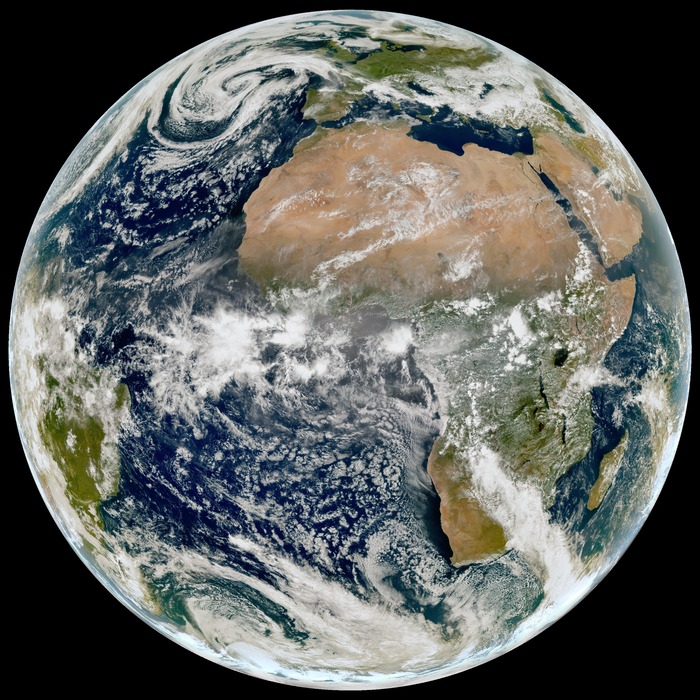

In [14]:
im = Image.open(output + '/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.jpg', 'r')
display(im)

Image Geocolor RGB, en vue geos, depuis le satellite Meteosat-12 positionnée en 0° 0°
Il s'agit d'un fichier type d'une production CMS envoyée par Transmet à Toulouse

<div class="alert alert-info alert-success">
2 - Différents formats
</div>

Le format jpg est un format très utilisé car le rendu visuel est très bon et c'est un format léger</br>
Son inconvénient : il est compressé, avec une qualité 92 par défaut, et même en forçant une compression à 100 il y a quand même une altération.</br>
Pour ne pas avoir de compression, il faut faire du tif ou du png.</br>
Les différences visuelles sont souvent très ténues, voire invisibles, l'interpolation par défaut "Lanczos" est un très bon compromis netteté / aliasing (pixellisation visible).</br>
Mais les poids sont très différents :
Exemples de poids de formats :

In [25]:
!convert -resize 700x700 /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT[3]  $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.jpg  >/dev/null 2>&1 
!convert -resize 700x700 /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT[3]  $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif  >/dev/null 2>&1 
!convert -resize 700x700 /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT[3]  $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.png  >/dev/null 2>&1 
!identify -quiet -format "%f : %b\n" $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700*.tif

globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif : 1.47028MB
globeMtruecolorGTP.mtg.20260422.1200.24_700x700_3857.tif : 1.46617MB
globeMtruecolorGTP.mtg.20260422.1200.24_700x700_4326.tif : 1.44222MB
globeMtruecolorGTP.mtg.20260422.1200.24_700x700_compress.tif : 430536B


Le format png est environ 4 fois plus lourd que le jpg. Le format tif est environ 7 fois plus lourd que le jpg.

In [16]:
!gdalinfo $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif

Driver: GTiff/GeoTIFF
Files: RESULTS/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif
Size is 700, 700
Image Structure Metadata:
  INTERLEAVE=PIXEL
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  700.0)
Upper Right (  700.0,    0.0)
Lower Right (  700.0,  700.0)
Center      (  350.0,  350.0)
Band 1 Block=700x496 Type=Byte, ColorInterp=Red
Band 2 Block=700x496 Type=Byte, ColorInterp=Green
Band 3 Block=700x496 Type=Byte, ColorInterp=Blue


###  Le géoréférencement est perdu.
L'utilisation de la commande convert a fait perdre le géoréférencement. </br>
Pour le conserver il utiliser la commande gdalwarp et produire un autre TIF, qui est le seul de ces 3 formats qui garde le géoréférencement.</br>
Cette commande crée une nouvelle image en 700x700 pixels.

In [26]:
!gdalwarp -overwrite -ts 700 700 /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT  $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif  

Creating output file that is 700P x 700L.
Processing /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


In [27]:
!gdalinfo $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif

Driver: GTiff/GeoTIFF
Files: RESULTS/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif
Size is 700, 700
Coordinate System is:
PROJCRS["unnamed",
    BASEGEOGCRS["GCS_unamed_ellipse",
        DATUM["unknown",
            ELLIPSOID["unamed",6378169,295.488065897,
                LENGTHUNIT["metre",1,
                    ID["EPSG",9001]]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["Degree",0.0174532925199433]]],
    CONVERSION["unnamed",
        METHOD["Geostationary Satellite (Sweep Y)"],
        PARAMETER["Longitude of natural origin",0,
            ANGLEUNIT["Degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Satellite Height",35786400,
            LENGTHUNIT["meter",1]],
        PARAMETER["False easting",0,
            LENGTHUNIT["meter",1],
            ID["EPSG",8806]],
        PARAMETER["False northing",0,
            LENGTHUNIT["meter",1],
            ID["EPSG",8807]]],
    CS[Cartesian,2],
        AXIS["(E)",east,
            ORDER[1],
     

On retrouve les métadonnées de géoréférencement.

Il est possible de compresser un tif. </br>
La compression LZW est "sans perte", mais le gain de poids est faible
La compression YCbCr (Luminance/couleur) est très efficace. Le gain en poids est important, mais il y a des pertes (infimes, souvent invisibles, mais existantes)

In [36]:
#!gdalwarp -overwrite -ts 700 700 /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_compress_YCbCr.tif -co COMPRESS=JPEG -co JPEG_QUALITY=100 -co PHOTOMETRIC=YCBCR >/dev/null 2>&1
!gdalwarp -overwrite -ts 700 700 /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_compress_LZW.tif -co COMPRESS=LZW -co PREDICTOR=2  #>/dev/null 2>&1
!identify -quiet -format "%f : %b\n" $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_compress_YCbCr.tif 
!identify -quiet -format "%f : %b\n" $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_compress_LZW.tif 

Creating output file that is 700P x 700L.
Processing /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
globeMtruecolorGTP.mtg.20260422.1200.24_700x700_compress_YCbCr.tif : 430536B
globeMtruecolorGTP.mtg.20260422.1200.24_700x700_compress_LZW.tif : 1.08873MB


Le poids du tif compressé LZW est ici environ 30% moins élevé que le tif non compressé. </br>
Le poids du tif compressé YCbCr est ici environ 4 fois plus petit que le tif non compressé.

<div class="alert alert-info alert-success">
3 - Reprojections
</div>

Gdal permet de faire des reprojections :

Exemple de  projection en **EPSG:4326 WGS84** (World Geodetic System 1984) </br>
Système de coordonnées basé sur la latitude et la longitude, unités en degrés (°). (EPSG:4326: Système géographique)</br>
Correspond visuellement à une cylindrique équidistante ou plate carrée

In [41]:
!gdalwarp -overwrite -t_srs EPSG:4326 $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_4326.tif
!gdalwarp -overwrite -t_srs EPSG:4326 $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_4326.jpg

Creating output file that is 767P x 626L.
Processing RESULTS/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 767P x 626L.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [42]:
!gdalinfo $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_4326.tif

Driver: GTiff/GeoTIFF
Files: RESULTS/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_4326.tif
Size is 767, 626
Coordinate System is:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        MEMBER["World Geodetic System 1984 (G2296)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["geodetic longi

On retrouve le système  WGS 84, </br>
Les coordonnées en latitude / longitude (degrés)

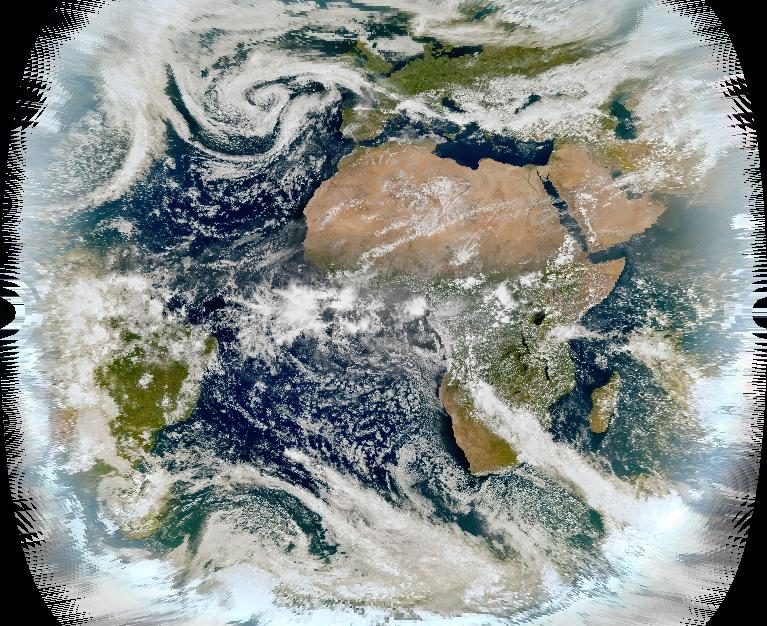

In [43]:
im2 = Image.open(output + '/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_4326.jpg', 'r')
display(im2)

---</br>
Autre exemple de reprojection : **Mercator** </br>
Projection cartographique de la Terre dite « cylindrique ». </br>
Référence dans le monde grâce à sa précision pour les voyages marins du fait de la conservation des angles qu'elle permet, essentielle pour prévoir les routes de navigation.

In [40]:
!gdalwarp -t_srs EPSG:3857 $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_3857.tif
!gdalwarp -t_srs EPSG:3857 $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_3857.jpg

Processing RESULTS/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
ERROR 1: Output dataset RESULTS/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_3857.jpg exists, but cannot be opened in update mode



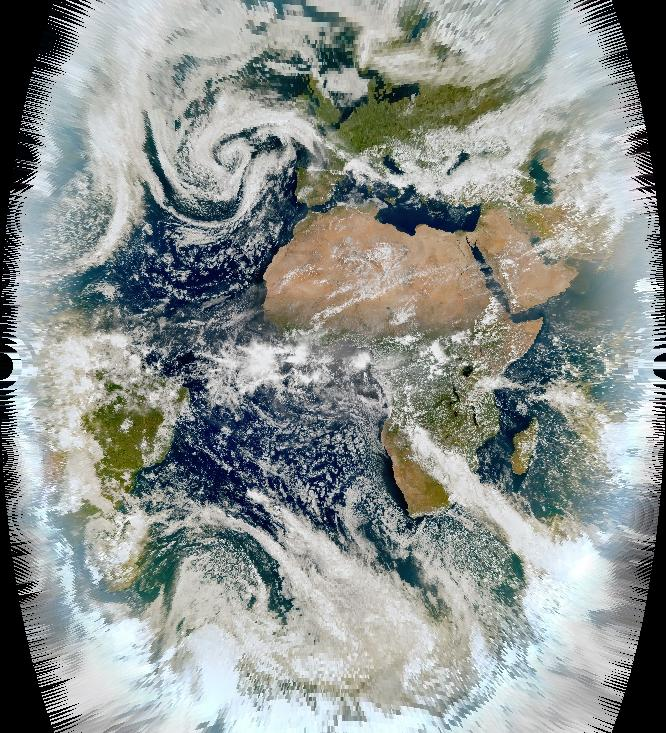

In [34]:
im3 = Image.open(output + '/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_3857.jpg', 'r')
display(im3)

---</br>
Autre exemple de reprojection : **Peters** </br>
ou projection de Gall-Peters, est une projection cartographique qui, contrairement à la projection de Mercator, permet de prendre en compte la superficie réelle des continents

In [66]:
!gdalwarp -overwrite -t_srs "+proj=cea +lon_0=0 +lat_ts=45 +x_0=0 +y_0=0 +ellps=WGS84 +units=m +no_defs" $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700.tif $output/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_peter.jpg

Creating output file that is 609P x 781L.
0...10...20...30...40...50...60...70...80...90...100 - done.


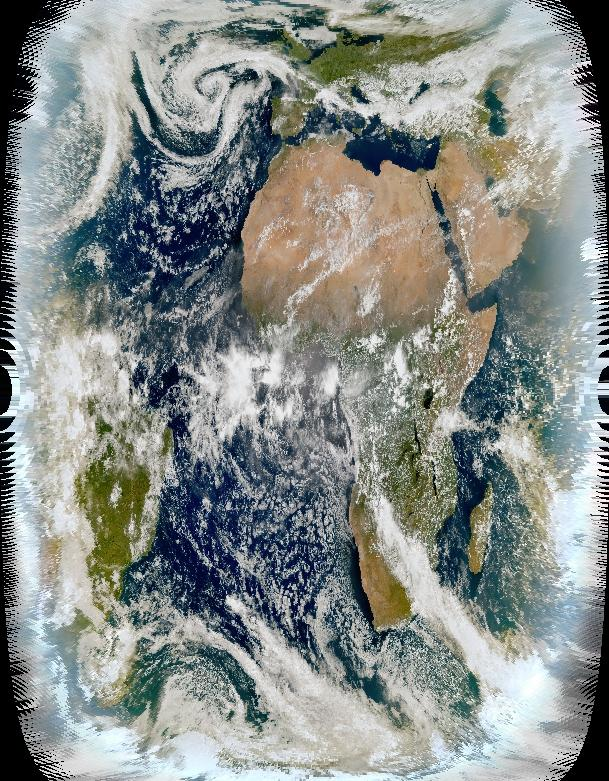

In [67]:
im3 = Image.open(output + '/globeMtruecolorGTP.mtg.20260422.1200.24_700x700_peter.jpg', 'r')
display(im3)

<div class="alert alert-info alert-success">
4 - Découpes
</div>

Exemple en **4326**.</br>
L'avantage de cette projection est qu'il est possible d'indiquer en entrée les coordonnées en degrés des limites de domaine (bbox)

In [66]:
# Exemple France avec un ratio 16/9 pour coordonnées du domaine : -te {coord_ouest} {coord_sud} {coord_est} {coord_nord}
# L'option -ts force la taille de sortie. 
# La source doit être un fichier tif géoréférencé. 
# Ici un fichier déjà en EPSG:4326 WGS 84
# option -t_srs pour la reprojection
# option -te pour indiquer la zone de découpe : dans l'ordre W S E N
# option -ts pour indiquer la taille de sortie
#!gdalwarp -overwrite -t_srs EPSG:4326 /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT $output/globeMtruecolorGTP.mtg.20260422.1200.24_4326.tif
#!gdalwarp -overwrite -te -14 38 18 56 -ts 960 540  $output/globeMtruecolorGTP.mtg.20260422.1200.24_4326.tif $output/globeMtruecolorGTP.mtg.20260422.1200.24_4326_france.jpg #W S E N en projection 16/9
# ou en 1 seule ligne à partir d'un fichier tif géoréférencé quelconque
!gdalwarp -overwrite -t_srs EPSG:4326 -te -14 38 18 56 -ts 960 540 /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT $output/globeMtruecolorGTP.mtg.20260422.1200.24_4326_france.jpg #W S E N en projection 16/9

Creating output file that is 960P x 540L.
0...10...20...30...40...50...60...70...80...90...100 - done.


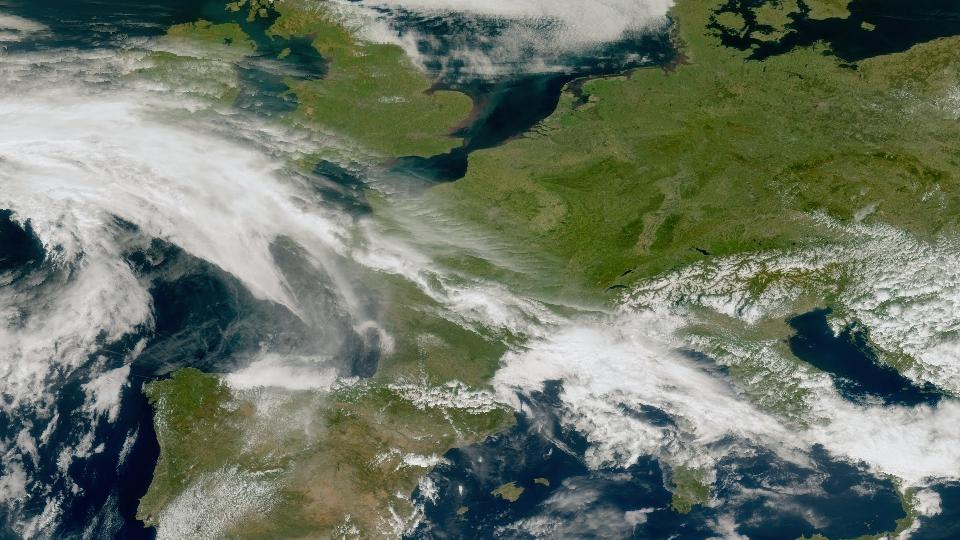

In [67]:
im4 = Image.open(output + '/globeMtruecolorGTP.mtg.20260422.1200.24_4326_france.jpg', 'r')
display(im4)

Creating output file that is 300P x 540L.
0...10...20...30...40...50...60...70...80...90...100 - done.


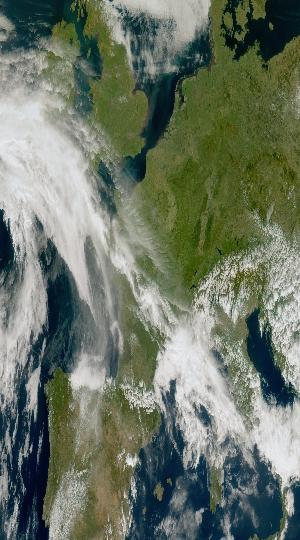

In [74]:
!gdalwarp -overwrite -t_srs EPSG:4326 -te -14 38 18 56 -ts 300 540 /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT $output/globeMtruecolorGTP.mtg.20260422.1200.24_4326_france_300x540.jpg #W S E N en projection 16/9
im5 = Image.open(output + '/globeMtruecolorGTP.mtg.20260422.1200.24_4326_france_300x540.jpg', 'r')
display(im5)

Attention ! L'image peut être déformée si le ratio de sortie est différent de celui de la zone de découpe

Exemple de découpe en projection **ortho** </br>
Une projection orthographique ("ortho") est une façon de représenter la Terre comme si on la regardait depuis très loin dans l'espace, à la verticale du point.

Creating output file that is 960P x 540L.
0...10...20...30...40...50...60...70...80...90...100 - done.


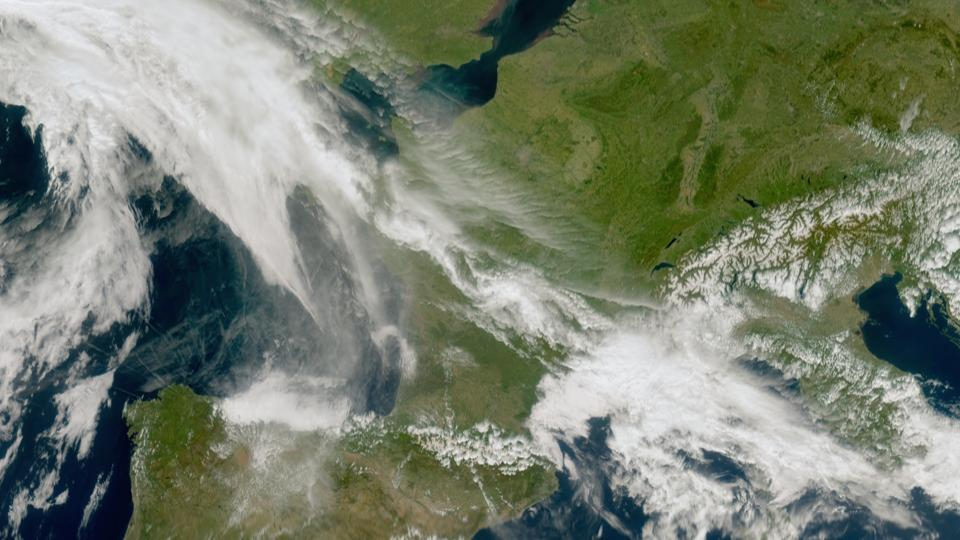

In [79]:
!gdalwarp -overwrite -t_srs '+proj=ortho lat_0=46.5 lon_0=1' -ts 960 540 -te -1120000 -630000 1120000 630000 -r cubic /stockage/DATA/TIF/20260422/EOXF71MTGG221200.globeMtruecolorGTP.mtg.20260422.1200.24.tif.LT  $output/globeMtruecolorGTP.mtg.20260422.1200.24_ortho_france_46.5_1.jpg
im6 = Image.open(output + '/globeMtruecolorGTP.mtg.20260422.1200.24_ortho_france_46.5_1.jpg', 'r')
display(im6)

La commande suivante permet de faire une RGB :

`!gdal_merge.py -separate band1.tif band2.tif band3.tif -o resultat.tif`

***Exercice 2 : faire une RGB natural color***

Le géoréférencement est conservé.

On peut afficher l'image :

In [ ]:
!gdalwarp -tr 0.1 -0.1 $output/20220905_1200_IR108_min-max_georef_4326.tif $output/20220905_1200_IR108_min-max_georef_4326_redim_tr.tif

***Exercice 3 : Découper une zone qui correspond à votre pays***

***Exercice 3 : Manipuler un fichier planisphère***

***Appliquer une palette exemple SST***

In [ ]:
# Exemple France avec un ratio 16/9 pour coordonnées du domaine : -te {coord_ouest} {coord_sud} {coord_est} {coord_nord}
!gdalwarp -te -14 38 18 56 -ts 1920 1080 -overwrite $output/20220905_1200_IR108_min-max_georef_4326.tif $output/20220905_1200_France.tif #W S E N

In [ ]:
!gdal_rasterize -b 1 -burn 255 -l world-administrative-boundaries $metadonnees/boundary/world-administrative-boundaries.shp $output/20220905_1200_France.tif

On peut aussi rajouter les graticules.

In [ ]:
!gdal_rasterize -b 1 -burn 255 -l 10m-graticules-5 $metadonnees/graticules/10m-graticules-5.shp $output/20220905_1200_France.tif
!convert -resize 800 $output/20220905_1200_France.tif $output/20220905_1200_France.jpg
im = Image.open(output + '/20220905_1200_France.jpg', 'r')
display(im)

**Attention !!!**

La commande gdal_rasterize écrase l'image qui est donnée en entrée.

In [ ]:
!gdal_translate -scale 180 255 0 255 $output/20220905_1200_France.tif $output/20220905_1200_France_seuil.tif
!convert -resize 800  $output/20220905_1200_France_seuil.tif  $output/20220905_1200_France_seuil.jpg

***Exercice 5 : Trouver un seuillage qui ne fasse apparaitre que les nuages***

Faire l'exercice dans cette cellule

Ensuite il est possible de mettre en transparent les zones qui sont noires :
    
`!gdalwarp -srcnodata '0' -dstalpha -dstnodata '0,0' in.tif image_transparente.tif`

In [ ]:
!gdal_translate -scale 100 200 0 255 $output/20220905_1200_France.tif $output/20220905_1200_France_seuil.tif

In [ ]:
!gdalwarp -srcnodata '0' -dstalpha -dstnodata '0,0' $output/20220905_1200_France_seuil.tif $output/20220905_1200_France_transp.tif

In [ ]:
!convert -resize 700  $output/20220905_1200_France_transp.tif $output/20220905_1200_France_transp.jpg

In [ ]:
im = Image.open(output + '/20220905_1200_France_transp.jpg', 'r')
display(im)

Découpage d'un fond de carte sur son pays :
Exemple pour la France :

In [ ]:
!gdalwarp -te -14 38 18 56 -ts 1920 1080 -overwrite /stockage/DATA/world.200408.3x21600x10800.tif $output/Fond_france-petit.tif
!convert -resize 700  $output/Fond_france-petit.tif $output/Fond_france-petit.jpg

In [ ]:
im = Image.open(output + '/Fond_france-petit.jpg', 'r')
display(im)

***Exercice 6 : découper un fond de carte qui correspond à la zone découpée précedemment***

superposition des nuages au fond de carte :

In [ ]:
img = Image.open(output + '/20220905_1200_France_transp.tif', 'r')
fond = Image.open(output + '/Fond_france-petit.tif', 'r')
fond.paste(img, (0,0), img)
fond.save(output + '/20220905_1200_France_fond.tif',"TIFF")
!convert -resize 700  $output/20220905_1200_France_fond.tif $output/20220905_1200_France_fond.jpg
im = Image.open(output + '/20220905_1200_France_fond.jpg', 'r')
display(im)

Ajout d'un logo sur l'image.

In [ ]:
logo1 = Image.open(metadonnees + '/Republique_Francaise_RVB.png')
petit_logo1 = logo1.resize((135,123), resample=0)
petit_logo1.save(output + '/petit_logo1.png')

In [ ]:
logo2 = Image.open(metadonnees + '/logo_mf_zoom.png')
petit_logo2 = logo2.resize((123,123), resample=0)
petit_logo2.save(output + '/petit_logo2.png')

In [ ]:
img = Image.open(output + '/20220905_1200_France_fond.tif', 'r')
petit_logo1 = Image.open(output + '/petit_logo1.png', 'r')
petit_logo2 = Image.open(output + '/petit_logo2.png', 'r')
img.paste(petit_logo1, (41,900))
img.paste(petit_logo2, (1700,900))
img.save(output + '/20220905_1200_France_fond_logo.tif')
!convert -resize 2000  $output/20220905_1200_France_fond_logo.tif $output/20220905_1200_France_fond_logo_HD.jpg
!convert -resize 700  $output/20220905_1200_France_fond_logo.tif $output/20220905_1200_France_fond_logo.jpg
im = Image.open(output + '/20220905_1200_France_fond_logo.jpg', 'r')
display(im)


<div class="alert alert-info" role="alert">

## <a id='section1'></a>Exercice : faire une image pour son pays avec le logo de son institution.

</div>